<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/leon/Asah_Fetch_A25_CS328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [ ]:
# Library Essential
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import shutil
from google.colab import files
from datetime import datetime

# Library pre-processing data
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Library save model (joblib)
import joblib

# **Load Dataset**

Load dataset yang dari Kaggle:
- Online Retail Dataset (UCI)
- Online Retail Dataset II (UCI)

In [2]:
# Upload file .json untuk API key
files.upload()
print("API Key Received")

Saving kaggle.json to kaggle.json
API Key Received


In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d viridianachow/online-retail-uci-dataset
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
  0% 0.00/7.15M [00:00<?, ?B/s]
100% 7.15M/7.15M [00:00<00:00, 927MB/s]
Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
  0% 0.00/14.5M [00:00<?, ?B/s]
100% 14.5M/14.5M [00:00<00:00, 1.33GB/s]


In [4]:
!unzip "online-retail-uci-dataset.zip"
!unzip "online-retail-ii-uci.zip"

Archive:  online-retail-uci-dataset.zip
  inflating: Online Retail.csv       
Archive:  online-retail-ii-uci.zip
  inflating: online_retail_II.csv    


In [5]:
# Simpan dataset dari csv ke DataFrame Pandas
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [8]:
df_1.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom


In [9]:
df_2.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) untuk mencari dari pola data pembelian

In [10]:
# Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [11]:
# Gabung menjadi 1 DataFrame
df_all = pd.concat([df_1, df_2])
df_all.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Informasi Dataset

In [12]:
# Tampilkan info dataset
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


In [14]:
df_all.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,1609280,1609280,1603444,1.609280e+06,1609280,1.609280e+06,1.231193e+06,1609280
unique,53628,5305,5698,NaN,70895,NaN,NaN,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,2228,8142,8287,NaN,1350,NaN,NaN,1476808
mean,NaN,NaN,NaN,9.808698e+00,NaN,4.636499e+00,1.531243e+04,NaN
std,NaN,NaN,NaN,1.892047e+02,NaN,1.152285e+02,1.702901e+03,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,1.234600e+04,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,1.396900e+04,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,1.522000e+04,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.130000e+00,1.679500e+04,NaN


### Korelasi Antar Variabel

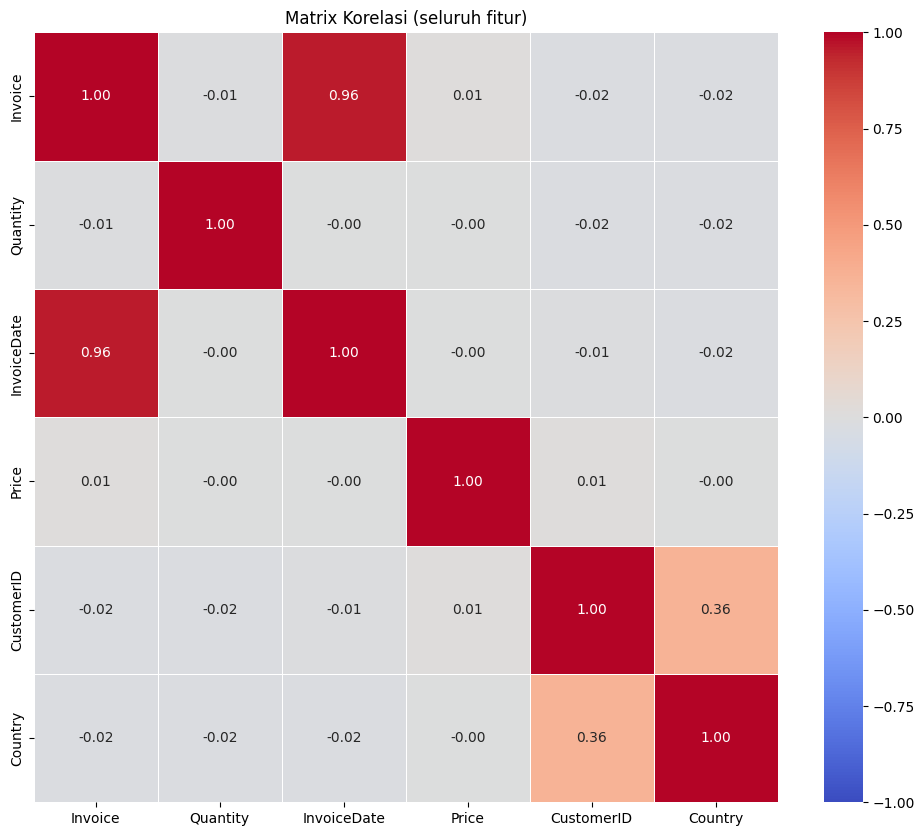

In [19]:
# Encode variabel kategorikal yang relevan
label_encoder = LabelEncoder()
df_lencoder = df_all.drop(['StockCode', 'Description'], axis=1)

# Konversi tanggal ke format yang sesuai
df_lencoder['InvoiceDate'] = pd.to_datetime(df_lencoder['InvoiceDate'], format='mixed')
category_features = ['Invoice', 'CustomerID', 'Country']
for col in category_features:
  df_lencoder[col] = label_encoder.fit_transform(df_all[col])

plt.figure(figsize=(12, 10))
matrix_korelasi = df_lencoder.corr()

sns.heatmap(matrix_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrix Korelasi')
plt.show()

In [47]:
column_display = ['Quantity', 'InvoiceDate', 'Price']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column_display, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_all[column], bins=10, kde=True, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7ed41d8a0e00> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7ed406009940> (for post_execute):


KeyboardInterrupt: 

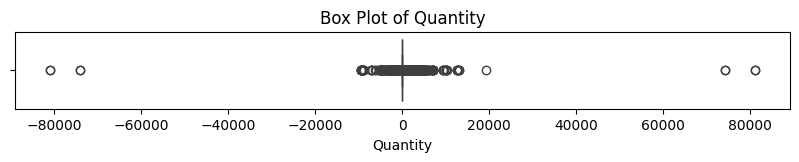

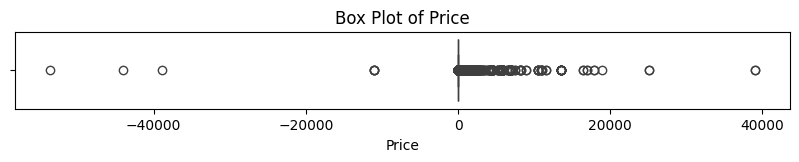

In [44]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_all[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

# **Data Cleaning & Preprocessing**

### Data Cleaning

##### Hapus missing values dan data duplikat

In [62]:
print("Data duplikat:", df_all.duplicated().sum())

print("Data hilang: ")
missing_values = df_all.isnull().sum()
missing_values[missing_values > 0]

Data duplikat: 39603
Data hilang: 


,0
Description,5836
CustomerID,378087


In [73]:
# Hapus data duplikat
df_clean = df_all.drop_duplicates()

# Hapus data hilang
filter_custID = (df_clean['CustomerID'].notnull() & df_clean['Description'].notnull())
df_clean = df_clean[filter_custID]

In [74]:
# Cek informasi dataset setelah cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199489 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1199489 non-null  object 
 1   StockCode    1199489 non-null  object 
 2   Description  1199489 non-null  object 
 3   Quantity     1199489 non-null  int64  
 4   InvoiceDate  1199489 non-null  object 
 5   Price        1199489 non-null  float64
 6   CustomerID   1199489 non-null  float64
 7   Country      1199489 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 82.4+ MB


##### Hapus data negatif

In [48]:
# Buat & apply filter untuk data negatif
filter_price = df_clean['Price'] >= 0
df_clean = df_clean[filter_price]
filter_quantity = df_clean['Quantity'] >= 0
df_clean = df_clean[filter_quantity]

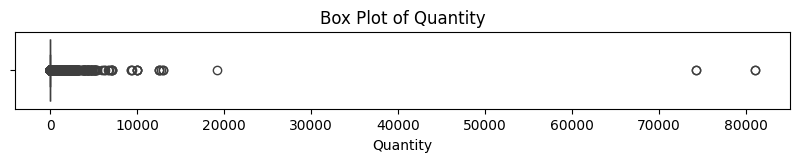

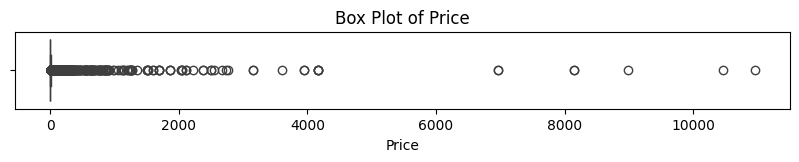

In [49]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_clean[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172227 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1172227 non-null  object 
 1   StockCode    1172227 non-null  object 
 2   Description  1172227 non-null  object 
 3   Quantity     1172227 non-null  int64  
 4   InvoiceDate  1172227 non-null  object 
 5   Price        1172227 non-null  float64
 6   CustomerID   1172227 non-null  float64
 7   Country      1172227 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 80.5+ MB


### Preprocessing Data

In [66]:
# Konversi format tanggal agar terstandarisasi
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed')

# Ubah CustomerID menjadi integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [70]:
df_clean = df_clean.sort_values('InvoiceDate')
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,2011-12-09 12:50:00,3.75,12680,France
541898,581587,22727,ALARM CLOCK BAKELIKE RED,4,2011-12-09 12:50:00,3.75,12680,France
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4,2011-12-09 12:50:00,3.75,12680,France
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680,France


# **Persiapan RFM**

### Recency:

### Frequency:

### Monetary: